#--- IMPORT PUSTAKA ---

In [1]:
# Import Pustaka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Untuk menyimpan model

# Sklearn Modules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import f_oneway  # Untuk Validasi Statistik

In [2]:
# Konfigurasi Visualisasi
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#--- MEMUAT DATA ---

In [5]:
from google.colab import files
import io

# Pemuatan dan Inspeksi Data
print("--- Pemuatan dan Inspeksi Data ---")

# Upload file dari komputer
# (Pastikan Anda mengunggah file DATA STOK TOMORO SEPTEMBER-2.xlsx)
uploaded = files.upload()

# Ambil nama file pertama yang diupload
file_name = list(uploaded.keys())[0]
print(f"File '{file_name}' berhasil diupload.")

try:
    # Baca file CSV atau Excel sesuai ekstensi
    if file_name.endswith('.csv'):
        df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    elif file_name.endswith(('.xls', '.xlsx')):
        df = pd.read_excel(io.BytesIO(uploaded[file_name]))
    else:
        raise ValueError("Format file tidak dikenali. Gunakan file CSV atau Excel.")

    print(f"File '{file_name}' berhasil dimuat ke dalam DataFrame.")

    # Tampilkan informasi dasar
    print("\nInformasi Data (df.info()):")
    df.info()

    # Tampilkan 5 baris pertama
    print("\n5 Baris Pertama Data (df.head()):")
    print(df.head())

    # Cek kolom penting
    required_cols = ['Item Code', 'Openning Balance', 'Sales']
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"\n⚠️ ERROR: Kolom yang diperlukan tidak ditemukan: {missing_cols}")
    else:
        print("\n✅ Kolom 'Item Code', 'Openning Balance', dan 'Sales' ditemukan.")

except Exception as e:
    print(f"\n❌ Terjadi error saat memuat data: {e}")

--- Pemuatan dan Inspeksi Data ---


Saving DATA STOK TOMORO SEPTEMBER.xlsx to DATA STOK TOMORO SEPTEMBER.xlsx
File 'DATA STOK TOMORO SEPTEMBER.xlsx' berhasil diupload.
File 'DATA STOK TOMORO SEPTEMBER.xlsx' berhasil dimuat ke dalam DataFrame.

Informasi Data (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store Code             2768 non-null   object 
 1   Store Name             2768 non-null   object 
 2   Item Code              2768 non-null   int64  
 3   Item Name              2768 non-null   object 
 4   Stock Unit             2768 non-null   object 
 5   FromDate               2768 non-null   object 
 6   ToDate                 2768 non-null   object 
 7   Openning Balance       2768 non-null   float64
 8   In-Transit             2768 non-null   int64  
 9   Supplier Receive       2768 non-null   int64  
 10  Internal Receive       2768 

#--- Data Cleaning & Preprocessing ---

In [6]:
print("--- Tahap 2: Data Cleaning ---")

# 1. Hapus baris jika kolom kunci kosong
df_clean = df.dropna(subset=['Item Code', 'Sales', 'Openning Balance']).copy()

# 2. Konversi tipe data ke numerik (menangani error jika ada teks di kolom angka)
df_clean['Sales'] = pd.to_numeric(df_clean['Sales'], errors='coerce')
df_clean['Openning Balance'] = pd.to_numeric(df_clean['Openning Balance'], errors='coerce')

# 3. Cek Duplikasi
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"   - Dihapus {duplicates} baris duplikat.")

# 4. Pastikan tidak ada nilai negatif pada Sales (jika ada retur, kita ambil absolutnya untuk clustering aktivitas)
df_clean['Sales'] = df_clean['Sales'].abs()

print(f"✅ Data Bersih: {df_clean.shape[0]} baris tersisa.")

--- Tahap 2: Data Cleaning ---
✅ Data Bersih: 2768 baris tersisa.


In [7]:
print("\n5 Baris Pertama Data Bersih (df_clean.head()):")
print(df_clean.head())


5 Baris Pertama Data Bersih (df_clean.head()):
  Store Code    Store Name  Item Code  \
0   CRB20A-M  Ciremai Raya   21010008   
1   CRB20A-M  Ciremai Raya   21020003   
2   CRB20A-M  Ciremai Raya   21020005   
3   CRB20A-M  Ciremai Raya   21020007   
4   CRB20A-M  Ciremai Raya   21020008   

                                      Item Name Stock Unit    FromDate  \
0                     Tomoro Master Coffee Bean       PACK  2025-09-01   
1         Whipping Cream (1ctn = 12pack x 1ltr)       PACK  2025-09-01   
2                Oat Milk (1ctn = 6pack x 1ltr)       PACK  2025-09-01   
3  Susu Kental Manis (1ctn = 24 pouch x 545 gr)      POUCH  2025-09-01   
4                           Barista Coconut 1 L       PACK  2025-09-01   

       ToDate  Openning Balance  In-Transit  Supplier Receive  ...  \
0  2025-09-02              4.78           0                 0  ...   
1  2025-09-02              5.50           0                 0  ...   
2  2025-09-02             13.25           0       

#--- Feature Engineering & Outlier Handling ---

In [8]:
print("--- Tahap 3: Feature Engineering ---")

# 1. Agregasi per Produk (Item Code)
# Kita ingin mengelompokkan PRODUK, bukan transaksi harian
df_agg = df_clean.groupby('Item Code').agg(
    ItemName=('Item Name', 'first'),
    TotalSales=('Sales', 'sum'),
    AvgStock=('Openning Balance', 'mean')
).reset_index()

print(f"   - Total Produk Unik: {df_agg.shape[0]}")

# 2. Handling Outliers dengan IQR Method
# K-Means sangat sensitif terhadap outlier (data yang terlalu ekstrem jauhnya)
def remove_outliers(data, columns):
    mask = np.ones(len(data), dtype=bool)
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Tandai data yang masih dalam batas wajar
        mask = mask & (data[col] >= lower_bound) & (data[col] <= upper_bound)
    return data[mask]

# Terapkan filter outlier
df_final = remove_outliers(df_agg, ['TotalSales', 'AvgStock']).copy()
print(f"   - Data setelah hapus outlier: {df_final.shape[0]} produk (siap dicluster).")

--- Tahap 3: Feature Engineering ---
   - Total Produk Unik: 97
   - Data setelah hapus outlier: 75 produk (siap dicluster).


#--- Scaling Data ---

In [9]:
print("--- Tahap 4: Scaling Data ---")

# Pilih fitur untuk clustering
features = ['TotalSales', 'AvgStock']
X = df_final[features]

# Standarisasi (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Buat DataFrame scaled untuk kemudahan visualisasi nanti
df_scaled = pd.DataFrame(X_scaled, columns=features)
print("✅ Data berhasil discaling.")
print(df_scaled.head(3))

--- Tahap 4: Scaling Data ---
✅ Data berhasil discaling.
   TotalSales  AvgStock
0   -0.217631  0.567709
1    0.925817  0.548712
2    0.285052 -0.262747


#--- Evaluasi Penentuan K (Elbow, Silhouette, DBI, CHI) ---

--- Tahap 5: Evaluasi Jumlah Cluster (K) ---


,K,Inertia,Silhouette,DBI,CHI
0,2,89.436130,0.607186,0.983487,49.433742
1,3,55.926435,0.572441,0.754077,60.555412
2,4,39.790222,0.514332,0.762853,65.551232
3,5,28.799745,0.484899,0.688085,73.646640
4,6,21.618066,0.476035,0.635483,81.953247
5,7,17.026148,0.431641,0.667554,88.513091
6,8,13.810179,0.463319,0.612781,94.389154
7,9,11.216462,0.485336,0.570078,102.078909


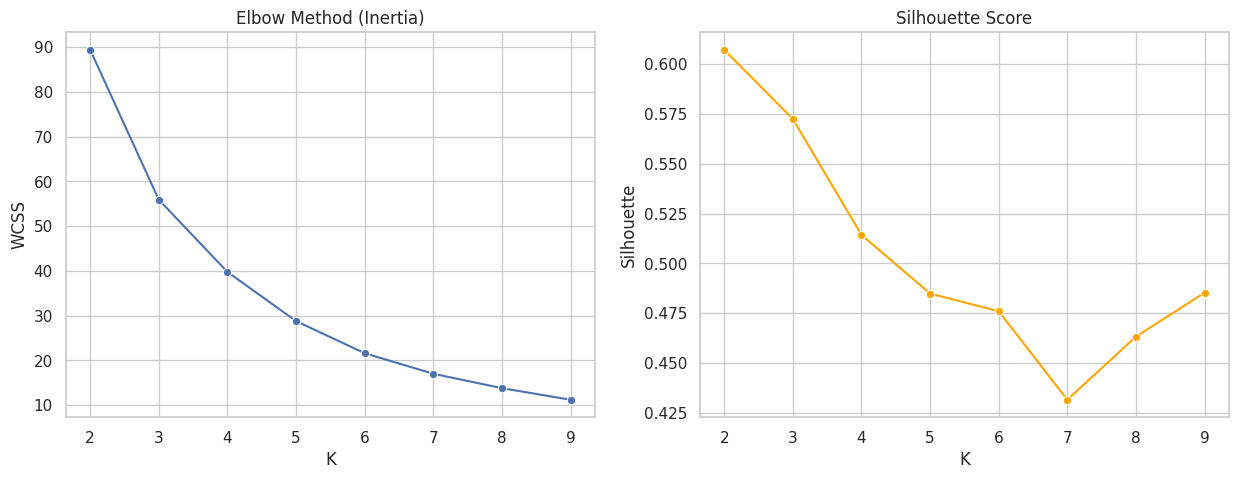

In [10]:
print("--- Tahap 5: Evaluasi Jumlah Cluster (K) ---")

metrics_results = []
K_range = range(2, 10)  # Coba K dari 2 sampai 9

for k in K_range:
    # Fit model sementara
    kmeans_test = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_test = kmeans_test.fit_predict(X_scaled)

    # Hitung Metrik
    inertia = kmeans_test.inertia_  # Elbow (makin kecil makin baik)
    sil = silhouette_score(X_scaled, labels_test) # (Makin dekat 1 makin baik)
    dbi = davies_bouldin_score(X_scaled, labels_test) # (Makin kecil makin baik)
    chi = calinski_harabasz_score(X_scaled, labels_test) # (Makin besar makin baik)

    metrics_results.append({
        'K': k,
        'Inertia': inertia,
        'Silhouette': sil,
        'DBI': dbi,
        'CHI': chi
    })

# Tampilkan Tabel Metrik
df_metrics = pd.DataFrame(metrics_results)
display(df_metrics.style.highlight_max(subset=['Silhouette', 'CHI'], color='lightgreen')
                     .highlight_min(subset=['DBI'], color='lightgreen'))

# Visualisasi Elbow & Silhouette
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot Elbow
sns.lineplot(data=df_metrics, x='K', y='Inertia', marker='o', ax=ax[0])
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_ylabel('WCSS')

# Plot Silhouette
sns.lineplot(data=df_metrics, x='K', y='Silhouette', marker='o', color='orange', ax=ax[1])
ax[1].set_title('Silhouette Score')
plt.show()

#--- Final Modeling & Saving ---

In [11]:
print("--- Tahap 6: Finalisasi Model ---")

# --- TENTUKAN K TERBAIK DISINI ---
# Berdasarkan grafik/tabel di atas, misal kita pilih K=3
BEST_K = 3

# 1. Fit Model Final
kmeans_final = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=42)
clusters = kmeans_final.fit_predict(X_scaled)

# 2. Masukkan hasil ke DataFrame asli
df_final['Cluster'] = clusters

# 3. Simpan Model (Penting untuk deployment/reuse)
joblib.dump(kmeans_final, 'model_kmeans_final.pkl')
joblib.dump(scaler, 'model_scaler_final.pkl')

print(f"✅ Model K-Means (K={BEST_K}) berhasil dilatih dan disimpan.")
print(df_final['Cluster'].value_counts().sort_index())

--- Tahap 6: Finalisasi Model ---
✅ Model K-Means (K=3) berhasil dilatih dan disimpan.
Cluster
0    57
1    13
2     5
Name: count, dtype: int64


#--- Visualisasi & PCA ---


--- Tahap 5: Visualisasi Hasil ---


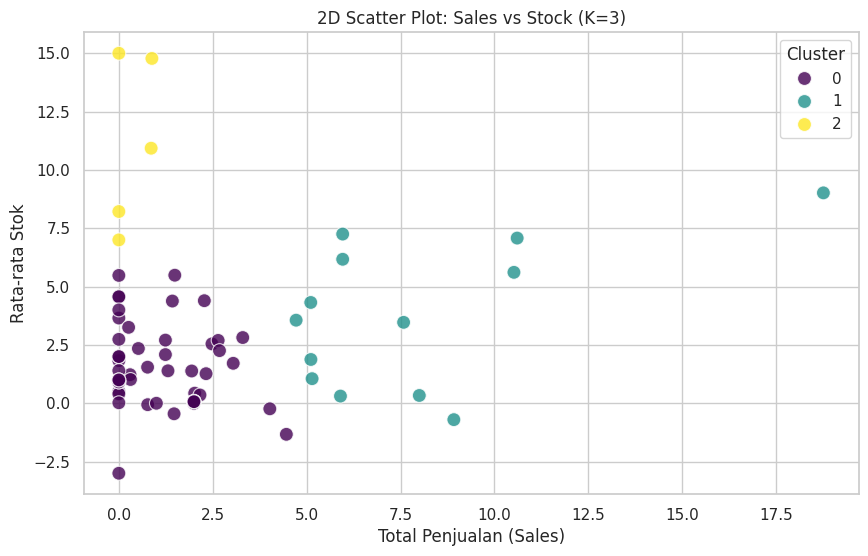

Menampilkan Plot 3D...


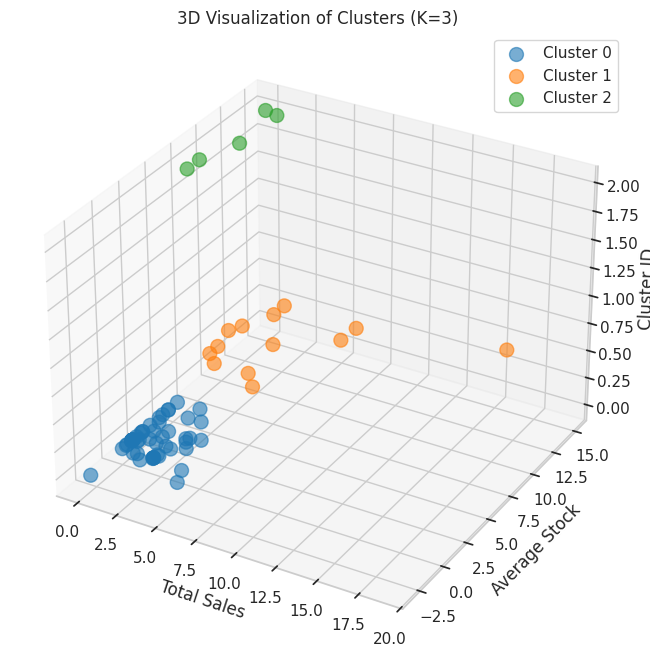

Menampilkan Diagram Batang...


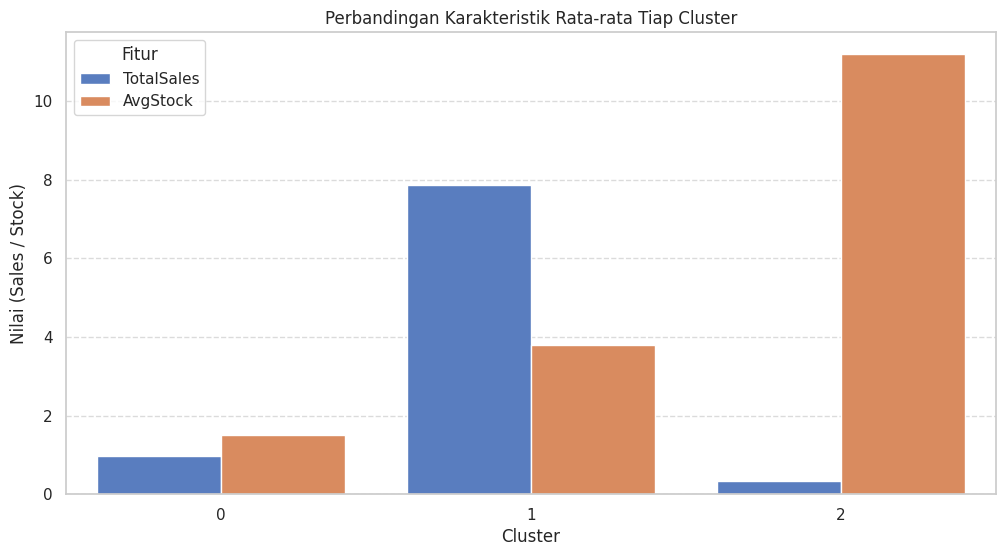


✅ Semua proses selesai!


In [16]:
print("\n--- Tahap 5: Visualisasi Hasil ---")

# --- A. Visualisasi 2D (PCA / Scatter) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='TotalSales', y='AvgStock', hue='Cluster', palette='viridis', s=100, alpha=0.8)
plt.title(f'2D Scatter Plot: Sales vs Stock (K={BEST_K})')
plt.xlabel('Total Penjualan (Sales)')
plt.ylabel('Rata-rata Stok')
plt.legend(title='Cluster')
plt.show()

# --- B. Visualisasi 3D (Kode Tambahan Anda) ---
print("Menampilkan Plot 3D...")
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Definisikan warna
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot setiap cluster
for i in sorted(df_final['Cluster'].unique()):
    cluster_data = df_final[df_final['Cluster'] == i]
    ax.scatter(
        cluster_data['TotalSales'],
        cluster_data['AvgStock'],
        cluster_data['Cluster'], # Z-axis = Cluster ID
        label=f'Cluster {i}',
        s=100,
        alpha=0.6,
        c=colors[i % len(colors)]
    )

ax.set_xlabel('Total Sales')
ax.set_ylabel('Average Stock')
ax.set_zlabel('Cluster ID')
ax.set_title(f'3D Visualization of Clusters (K={BEST_K})')
ax.legend()
plt.show()

# --- C. Visualisasi Diagram Batang (Bar Chart) ---
print("Menampilkan Diagram Batang...")
# Siapkan data untuk plotting (Agregasi Rata-rata)
cluster_means = df_final.groupby('Cluster')[['TotalSales', 'AvgStock']].mean().reset_index()

# "Melt" data agar bisa di-plot side-by-side
df_melted = cluster_means.melt(id_vars="Cluster", var_name="Fitur", value_name="Rata-rata Nilai")

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Cluster', y='Rata-rata Nilai', hue='Fitur', palette='muted')

plt.title('Perbandingan Karakteristik Rata-rata Tiap Cluster')
plt.ylabel('Nilai (Sales / Stock)')
plt.xlabel('Cluster')
plt.legend(title='Fitur')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n✅ Semua proses selesai!")

#--- Validasi Statistik (ANOVA) ---

In [13]:
print("--- Tahap 8: Validasi Statistik (One-Way ANOVA) ---")
print("H0: Rata-rata antar cluster sama (Cluster gagal).")
print("H1: Setidaknya satu cluster berbeda secara signifikan (Cluster berhasil).\n")

for col in features:
    # Mengambil data tiap fitur untuk setiap cluster
    groups = [df_final[df_final['Cluster'] == c][col] for c in sorted(df_final['Cluster'].unique())]

    # Uji ANOVA
    f_stat, p_value = f_oneway(*groups)

    significance = "✅ SIGNIFIKAN (Beda Nyata)" if p_value < 0.05 else "❌ TIDAK SIGNIFIKAN"
    print(f"Fitur: {col:15} | F-Score: {f_stat:.2f} | P-Value: {p_value:.5e} -> {significance}")

--- Tahap 8: Validasi Statistik (One-Way ANOVA) ---
H0: Rata-rata antar cluster sama (Cluster gagal).
H1: Setidaknya satu cluster berbeda secara signifikan (Cluster berhasil).

Fitur: TotalSales      | F-Score: 72.47 | P-Value: 5.70338e-18 -> ✅ SIGNIFIKAN (Beda Nyata)
Fitur: AvgStock        | F-Score: 51.00 | P-Value: 1.59965e-14 -> ✅ SIGNIFIKAN (Beda Nyata)


#--- Profiling & Interpretasi Bisnis ---

In [14]:
print("--- Tahap 9: Profiling & Strategi Bisnis ---")

# Hitung rata-rata Sales & Stock per Cluster
profile = df_final.groupby('Cluster')[['TotalSales', 'AvgStock']].mean().reset_index()
profile['Count'] = df_final.groupby('Cluster')['Item Code'].count().values

# Fungsi otomatis untuk memberi label bisnis berdasarkan data
def assign_business_label(row, global_sales_mean, global_stock_mean):
    if row['TotalSales'] > global_sales_mean and row['AvgStock'] > global_stock_mean:
        return "Star Product (Jaga Stok)"
    elif row['TotalSales'] > global_sales_mean and row['AvgStock'] <= global_stock_mean:
        return "Fast Moving (Perlu Restock)"
    elif row['TotalSales'] <= global_sales_mean and row['AvgStock'] > global_stock_mean:
        return "Slow Moving (Overstock - Diskon)"
    else:
        return "Dead Stock (Evaluasi)"

# Hitung rata-rata global sebagai baseline
g_sales = df_final['TotalSales'].mean()
g_stock = df_final['AvgStock'].mean()

# Terapkan label
profile['Strategi'] = profile.apply(assign_business_label, axis=1, args=(g_sales, g_stock))

display(profile)

--- Tahap 9: Profiling & Strategi Bisnis ---


,Cluster,TotalSales,AvgStock,Count,Strategi
0,0,0.972614,1.516971,57,Dead Stock (Evaluasi)
1,1,7.869077,3.795438,13,Star Product (Jaga Stok)
2,2,0.348000,11.185078,5,Slow Moving (Overstock - Diskon)


#--- Simpan Hasil (Export) ---

In [17]:
print("--- Tahap 10: Export Data ---")

# Gabungkan label strategi ke data utama
df_export = df_final.merge(profile[['Cluster', 'Strategi']], on='Cluster', how='left')

# Simpan ke Excel
output_file = 'HASIL_CLUSTERING_TOMORO.xlsx'
df_export.to_excel(output_file, index=False)

print(f"✅ File hasil berhasil disimpan: {output_file}")
# Jika di Google Colab, uncomment baris di bawah untuk auto-download
# from google.colab import files
# files.download(output_file)

--- Tahap 10: Export Data ---
✅ File hasil berhasil disimpan: HASIL_CLUSTERING_TOMORO.xlsx
